In [134]:
import queer
from queer.utils import path_create
from queer.mesh import mesh_crystal,mesh_cartesian,cartesian2crystal,crystal2cartesian
import numpy as np
from queer.arpes import arpes_mesh,arpes_mesh_plot,binding_k, arpes_equation
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Input files
file_path = "./vineet/"
hr = "wannier90_hr.dat"
model = queer.model(path=file_path,ef=5.8554,poscar='POSCAR')

In [3]:
k_points = 800
custom_points = [
    [1/2, 0, 0],   # M
    [0, 0, 0],     # Gamma
    [1/2, 0, 0],   # M
    [1/3, 1/3, 0], # K
    [0, 0, 0],      # Back to Gamma
    [1/3, 1/3, 0] # K
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['M','Γ', 'M', 'K', 'Γ', 'K']

Calculating band structure...
Plotting band structure...


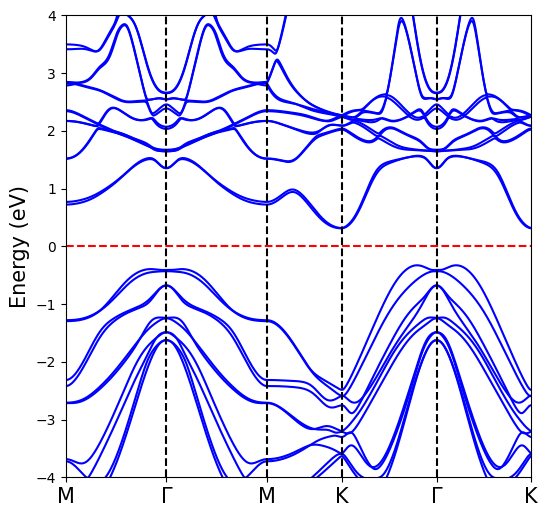

In [4]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


In [77]:
binding = np.arange(0,3.1,1)
V0=[5,10,15]
x = np.linspace(-2.5, 2.5, 100)
# y is zero
y = np.zeros(100)
# stack into a 2×N array
x_path = np.vstack((x, y))
g_vec = model.g_vec

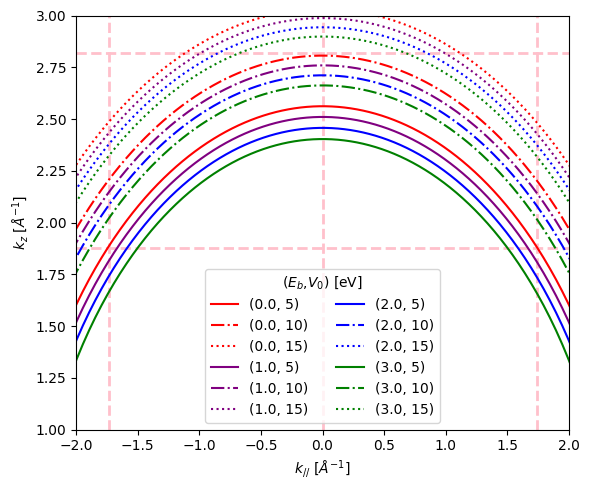

In [127]:
line_style = ['-',"-.",":"]
color = ['red','purple','blue','green']
fig = plt.figure(figsize=(6,5))
for i in range(4):
    plt.axhline(i*np.linalg.norm(g_vec[-1]),color='pink', linestyle='--', linewidth=2)
for i in range(-1,2):
    plt.axvline(i*np.linalg.norm(g_vec[-2]),color='pink', linestyle='--', linewidth=2)
for j,b in enumerate(binding):
    for i,v in enumerate(V0):
        kz = arpes_equation(20-b,v,x_path)
        plt.plot(x,kz,label=f"({b}, {v})",linestyle=line_style[i],color=color[j])

    plt.xlim(-2,2)
    plt.ylim(1,3)
    # plt.axis("equal")
    plt.legend(title=r'$(E_{b}$,$V_{0}$) [eV]',ncol=2,loc="lower center")
    plt.xlabel(r"$k_{//}$ [$\AA^{-1}$]")
    plt.ylabel(r"$k_z$ [$\AA^{-1}$]")
plt.tight_layout()
plt.savefig("./figs/arpes_cut", dpi=300, bbox_inches='tight')


In [5]:
# mesh_3d = mesh_cartesian([400,400,1],factor=2)

In [254]:
photon_energy = 21.2
fermi_energy= 0.2
V0 = 10
N = 200
factor = 4
binding_range = [0,3.1]
binding_step = 0.5
kmesh_dict = binding_k(photon_energy,fermi_energy,binding_range,binding_step,V0,N,factor)

/scratch/s.sevim/Dev/queer/queer/arpes.py:32: RuntimeWarning: invalid value encountered in sqrt
  kz = np.sqrt(C * (Ek + V0) - kx**2 - ky**2)


In [255]:
kmesh_dict.keys()

dict_keys([np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0)])

In [257]:
energy_dict = {}
for i,j in kmesh_dict.items():
    kmesh = np.array(j)
    inv_kmesh = crystal2cartesian(kmesh,g_vec)
    band = model.calculate_energy(inv_kmesh)
    energy_dict[i] =band


In [258]:
energy_dict

{np.float64(0.0): array([[-51.67004273, -51.66763477, -51.66841236, ..., -51.66684387,
         -51.667754  , -51.67050585],
        [-51.66732702, -51.66607709, -51.66657062, ..., -51.66649796,
         -51.66260675, -51.66911102],
        [-51.25699253, -51.25525927, -51.25607565, ..., -51.25612363,
         -51.25497318, -51.25659669],
        ...,
        [ 14.31364267,  14.76105327,  14.62331561, ...,  14.62826517,
          14.73354563,  14.27561387],
        [ 15.06946654,  15.093906  ,  15.31035383, ...,  15.34846441,
          15.153848  ,  15.09056261],
        [ 15.09115961,  15.17845989,  15.41209999, ...,  15.40671748,
          15.23457395,  15.19291951]], shape=(72, 40000)),
 np.float64(0.5): array([[-51.66831711, -51.66764327, -51.66875757, ..., -51.66848933,
         -51.66913225, -51.66871594],
        [-51.6678468 , -51.66665141, -51.66623819, ..., -51.66694705,
         -51.66719531, -51.66795173],
        [-51.25699701, -51.25711985, -51.25586046, ..., -51.25567215

In [259]:
mesh_tile_dict = {}
band_tile_dict = {}
for i,j in kmesh_dict.items():
    kmesh = np.array(j)
    tile_mesh = []
    for k in range(energy_dict[i].shape[0]):
        tile_mesh.append(kmesh.T)
    mesh_tile = np.array(tile_mesh).reshape(-1,3)
    mesh_tile_dict[i]=mesh_tile
    band_tile = energy_dict[i].flatten()
    band_tile_dict[i]=band_tile

In [284]:
df_dict = {}
for i,j in kmesh_dict.items():
    mesh_tile = mesh_tile_dict[i]
    band_tile = band_tile_dict[i]
    df = pd.DataFrame()
    df['kx']=mesh_tile.T[0]
    df['ky']=mesh_tile.T[1]
    df['kz']=mesh_tile.T[2]
    df['e']=band_tile
    df_dict[i]=df

In [285]:
df_shift = { name: df.copy(deep=True) for name, df in df_dict.items() }


In [286]:
energy_shift = df_shift[0].query('e<=0').max().e

In [287]:
for i,j in df_shift.items():
    print(i,j.query('e<=0').max().e)
    j.e -= energy_shift
    print(i,j.query('e<=0').max().e)

0.0 -0.23850811277741446
0.0 0.0
0.5 -0.25850671476405473
0.5 -0.019998601986640274
1.0 -0.2834511747602484
1.0 -0.04494306198283393
1.5 -0.3119484988104668
1.5 -0.07344038603305236
2.0 -0.34727176660255665
2.0 -0.10876365382514219
2.5 -0.3544554552290995
2.5 -0.11594734245168503
3.0 -0.33546799371922464
3.0 -0.09695988094181018


In [301]:
intensity_dict = {}
for i,j in df_shift.items():
    j["I"]= np.exp(- ((j.e+i)**2) / (2 * 0.1**2))
    group_max = j.loc[j.groupby(['kx', 'ky'])['I'].idxmax()]
    intensity_dict[i]=group_max


In [314]:
len(intensity_dict)

7

In [327]:
import imageio


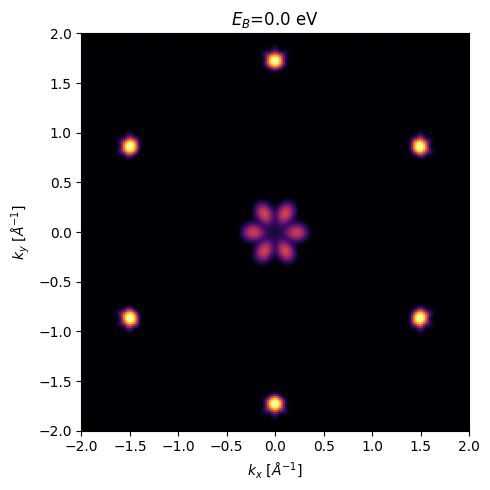

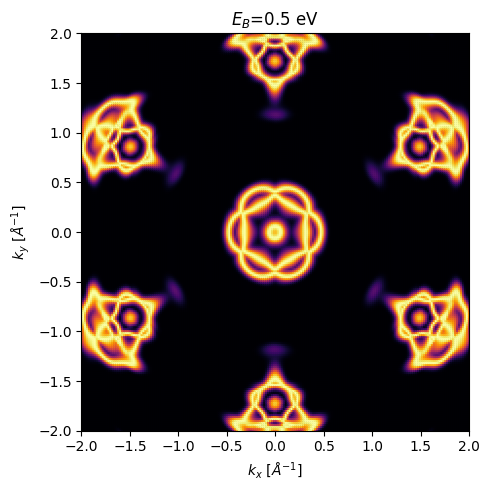

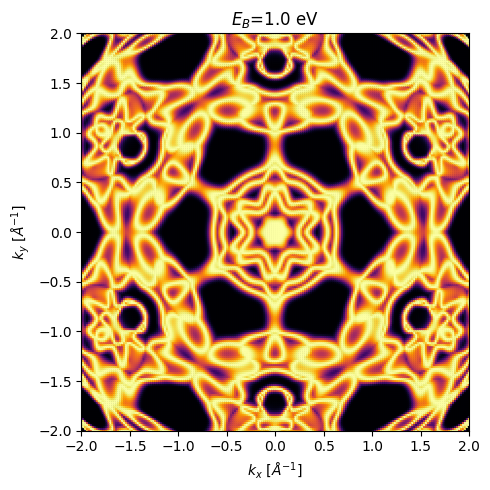

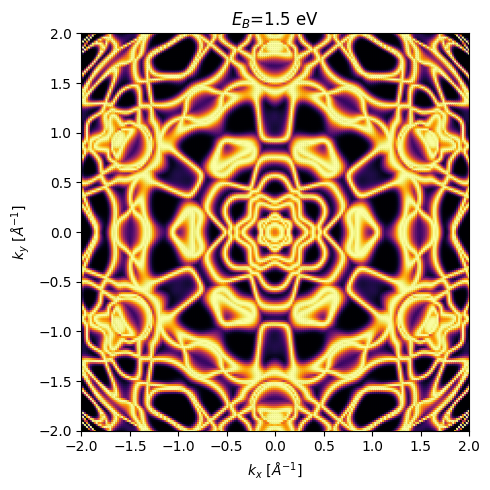

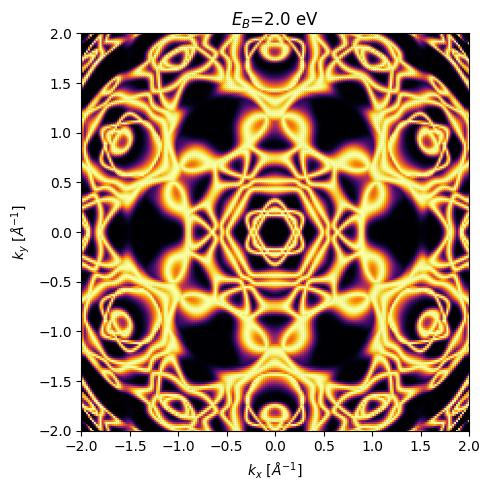

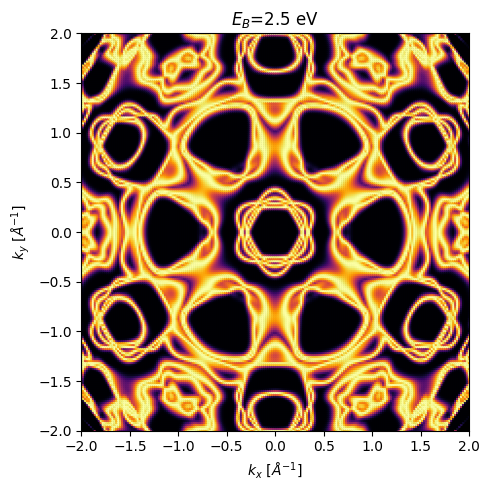

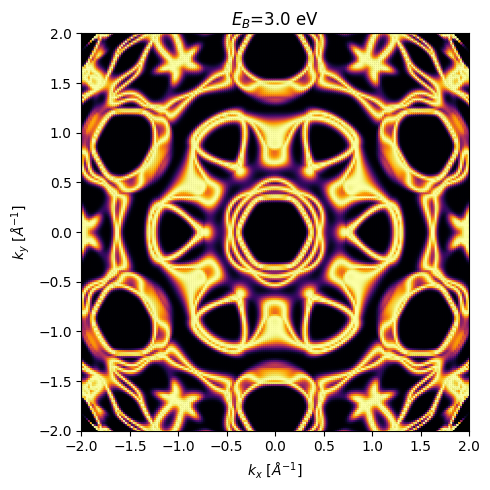

In [329]:
frame_files = []

for i,j in intensity_dict.items():
    fig = plt.figure(figsize=(5,5))
    plt.scatter(j.kx,j.ky,c=j.I,cmap='inferno',s=1)
    # plt.axis("equal")
    plt.xlabel(r"$k_{x}$ [$\AA^{-1}$]")
    plt.ylabel(r"$k_{y}$ [$\AA^{-1}$]")
    plt.title(fr"${{E_B}}$={i} eV")
    plt.gca().set_facecolor('black')
    plt.xlim(-2,2)
    plt.ylim(-2,2)
    plt.tight_layout()
    figure_path = f"./figs/{i}.png"
    plt.savefig(figure_path, dpi=300, bbox_inches='tight')
    frame_files.append(figure_path)
    plt.show()


In [341]:
import glob



In [346]:
import imageio.v2 as imageio  # Use v2 to avoid deprecation warning
import glob
from PIL import Image
import numpy as np

# Step 1: Get a sorted list of all PNG files in the directory
png_files = sorted(glob.glob('./figs/v0_10/*.png'))

# Step 2: Create a writer object for the video (MP4 format, 15 frames per second)
writer = imageio.get_writer('./figs/animation.mp4', fps=3)

# Step 3: Define a function to resize images to a uniform size
def resize_image(image_path, size=(1472, 1456)):
    img = Image.open(image_path)
    img = img.resize(size, Image.LANCZOS)  # Replace ANTIALIAS with LANCZOS
    return np.array(img)  # Convert to numpy array for imageio

# Step 4: Process each PNG file, resize it, and append it to the video
for png_file in png_files:
    resized_img = resize_image(png_file)
    writer.append_data(resized_img)

# Step 5: Close the writer to save the video
writer.close()

print("Video created successfully!")

[rawvideo @ 0x6d4abc0] Stream #0: not enough frames to estimate rate; consider increasing probesize


Video created successfully!


In [330]:
# Build GIF
gif_path = './figs/v0_10.gif'
with imageio.get_writer(gif_path, mode='I', duration=0.1) as writer:
    for fname in frame_files:
        img = imageio.imread(fname)
        writer.append_data(img)

/tmp/ipykernel_92639/3245688094.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(fname)


In [ ]:
movie_path = './figs/v0_10.mp4'
with imageio.get_writer(movie_path, fps=10, codec='mpeg4', macro_block_size=None) as writer:
    for frame in frame_files:
        writer.append_data(frame)


In [338]:
movie_path = './figs/v0_10.mp4'
with imageio.get_writer(
    movie_path,
    fps=10,
    codec='libx264',
    macro_block_size=None,
    ffmpeg_params=['-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2']
) as writer:
    for filename in frame_files:
        img = imageio.imread(filename)
        writer.append_data(img)

/tmp/ipykernel_92639/62395993.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(filename)


ValueError: All images in a movie should have same size

In [333]:
pip install imageio[ffmpeg]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 153.7 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [302]:
intensity_dict

{np.float64(0.0):           kx        ky        kz         e             I
 1480000 -2.0 -2.000000  0.370810 -0.942231  5.268364e-20
 1480001 -2.0 -1.979899  0.466367 -1.067252  1.846531e-25
 1480002 -2.0 -1.959799  0.544691 -0.970703  3.459173e-21
 1480003 -2.0 -1.939698  0.612429 -1.021956  2.095396e-23
 1480004 -2.0 -1.919598  0.672788 -1.178596  6.859774e-31
 ...      ...       ...       ...       ...           ...
 1519995  2.0  1.919598  0.672788 -1.176124  9.177104e-31
 1519996  2.0  1.939698  0.612429 -1.022573  1.967418e-23
 1519997  2.0  1.959799  0.544691 -0.973320  2.682389e-21
 1519998  2.0  1.979899  0.466367 -1.066603  1.978971e-25
 1519999  2.0  2.000000  0.370810 -0.942571  5.102214e-20
 
 [40000 rows x 5 columns],
 np.float64(0.5):           kx        ky        kz         e             I
 1480000 -2.0 -2.000000  0.079057 -1.502264  1.537516e-22
 1480001 -2.0 -1.979899  0.293680 -1.014792  1.759396e-06
 1480002 -2.0 -1.959799  0.406741 -0.980094  9.884945e-06
 1480003 

In [239]:
df_cal["I"]= np.exp(- (df_cal.e**2) / (2 * 0.1**2))

In [243]:
group_max = df.loc[df_cal.groupby(['kx', 'ky'])['I'].idxmax()]


In [244]:
group_max

,kx,ky,kz,e,I
1480000,-2.0,-2.000000,0.370810,-0.942231,5.268364e-20
1480001,-2.0,-1.979899,0.466367,-1.067252,1.846531e-25
1480002,-2.0,-1.959799,0.544691,-0.970703,3.459173e-21
1480003,-2.0,-1.939698,0.612429,-1.021956,2.095396e-23
1480004,-2.0,-1.919598,0.672788,-1.178596,6.859774e-31
...,...,...,...,...,...
1519995,2.0,1.919598,0.672788,-1.176124,9.177104e-31
1519996,2.0,1.939698,0.612429,-1.022573,1.967418e-23
1519997,2.0,1.959799,0.544691,-0.973320,2.682389e-21
1519998,2.0,1.979899,0.466367,-1.066603,1.978971e-25


In [242]:
df_cal.I.describe()

count     2.880000e+06
mean      3.030298e-04
std       1.292954e-02
min       0.000000e+00
25%       0.000000e+00
50%       0.000000e+00
75%      4.604615e-205
max       1.000000e+00
Name: I, dtype: float64

In [229]:
np.exp(- (df_adjusted[0].e**2) / (2 * 0.1**2))

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
2879995    0.0
2879996    0.0
2879997    0.0
2879998    0.0
2879999    0.0
Name: e, Length: 2880000, dtype: float64

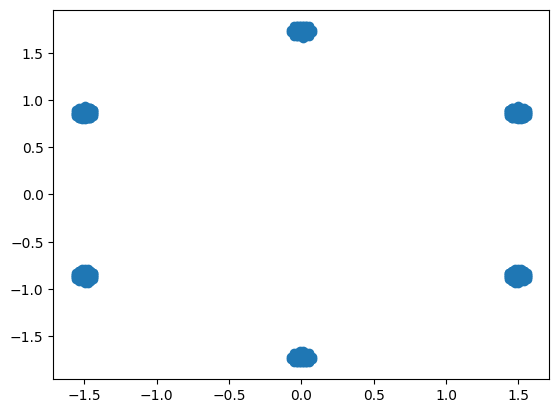

In [253]:
cal_q = df_cal.query('-0.1<=e<=0.1')
plt.scatter(cal_q.kx,cal_q.ky)


(np.float64(-2.2), np.float64(2.2), np.float64(-2.2), np.float64(2.2))

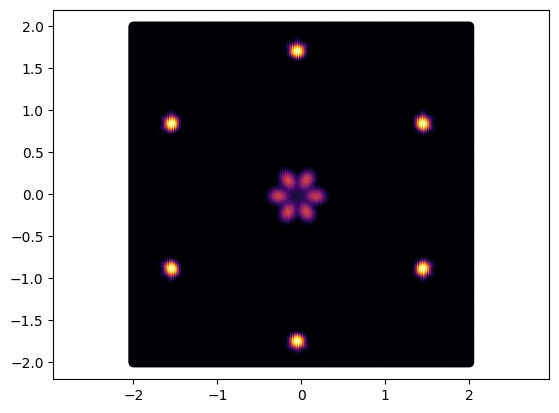

In [252]:
plt.scatter(group_max.kx,group_max.ky,c=group_max.I,cmap='inferno')
plt.axis("equal")

In [182]:
df_adjusted[0].query('e<=0').max().e

np.float64(0.0)

In [168]:
df_adjusted[0.0]['e'] -= df_adjusted[0.0].query('e<=0').max().e

In [171]:
 df_adjusted[0.0].query('e<=0')

,kx,ky,kz,e
0,-2.0,-2.000000,0.370810,-51.431535
1,-2.0,-1.979899,0.466367,-51.429127
2,-2.0,-1.959799,0.544691,-51.429904
3,-2.0,-1.939698,0.612429,-51.433008
4,-2.0,-1.919598,0.672788,-51.431818
...,...,...,...,...
1519995,2.0,1.919598,0.672788,-1.176124
1519996,2.0,1.939698,0.612429,-1.022573
1519997,2.0,1.959799,0.544691,-0.973320
1519998,2.0,1.979899,0.466367,-1.066603


In [153]:
df_adjusted[0.0].query('e<=0')

,kx,ky,kz,e
